# Visualizzazione della rete — early COVID dataset

Questo notebook legge il file `01-early_covid.csv`, costruisce un grafo diretto, estrae la componente debolmente connessa più grande e ne visualizza un sottografo campionato.


In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random


## Parametri principali

Puoi cambiare:
- `file_path` se il file ha un nome diverso
- `n_sample` per aumentare o diminuire il numero di nodi mostrati
- `seed` per ottenere sempre lo stesso campionamento/layout


In [2]:
file_path = '01-early_covid.csv'
n_sample = 1500   # prova 500, 1000, 1500, 2500
seed = 42


## Lettura del dataset

Assumiamo tre colonne: `source`, `target`, `weight`.


In [3]:
df = pd.read_csv(file_path, header=None, names=['source', 'target', 'weight'])
print(df.head())
print('\nNumero righe:', len(df))


   source  target  weight
0       0       1       1
1       0     476       1
2       0    2094       1
3       0    7969       1
4       0       3       2

Numero righe: 87749


## Costruzione del grafo diretto


In [4]:
G = nx.DiGraph()

for _, row in df.iterrows():
    G.add_edge(str(row['source']), str(row['target']), weight=row['weight'])

print('Nodi totali:', G.number_of_nodes())
print('Archi totali:', G.number_of_edges())


Nodi totali: 22759
Archi totali: 87749


## Estrazione della giant component

Per un grafo diretto usiamo la componente **debolmente connessa** più grande.


In [5]:
largest_cc = max(nx.weakly_connected_components(G), key=len)
Gcc = G.subgraph(largest_cc).copy()

print('Nodi giant component:', Gcc.number_of_nodes())
print('Archi giant component:', Gcc.number_of_edges())


Nodi giant component: 22726
Archi giant component: 87729


## Campionamento di un sottografo

Campioniamo un numero gestibile di nodi dalla giant component, poi rimuoviamo gli isolati e teniamo solo la componente principale del campione.


In [6]:
random.seed(seed)

sampled_nodes = random.sample(list(Gcc.nodes()), min(n_sample, Gcc.number_of_nodes()))
H = Gcc.subgraph(sampled_nodes).copy()

H.remove_nodes_from(list(nx.isolates(H)))

if H.number_of_nodes() > 0:
    largest_sub_cc = max(nx.weakly_connected_components(H), key=len)
    H = H.subgraph(largest_sub_cc).copy()

print('Nodi sottografo finale:', H.number_of_nodes())
print('Archi sottografo finale:', H.number_of_edges())


Nodi sottografo finale: 71
Archi sottografo finale: 72


## Layout e visualizzazione

Per campioni grandi conviene tenere archi sottili e nodi piccoli.


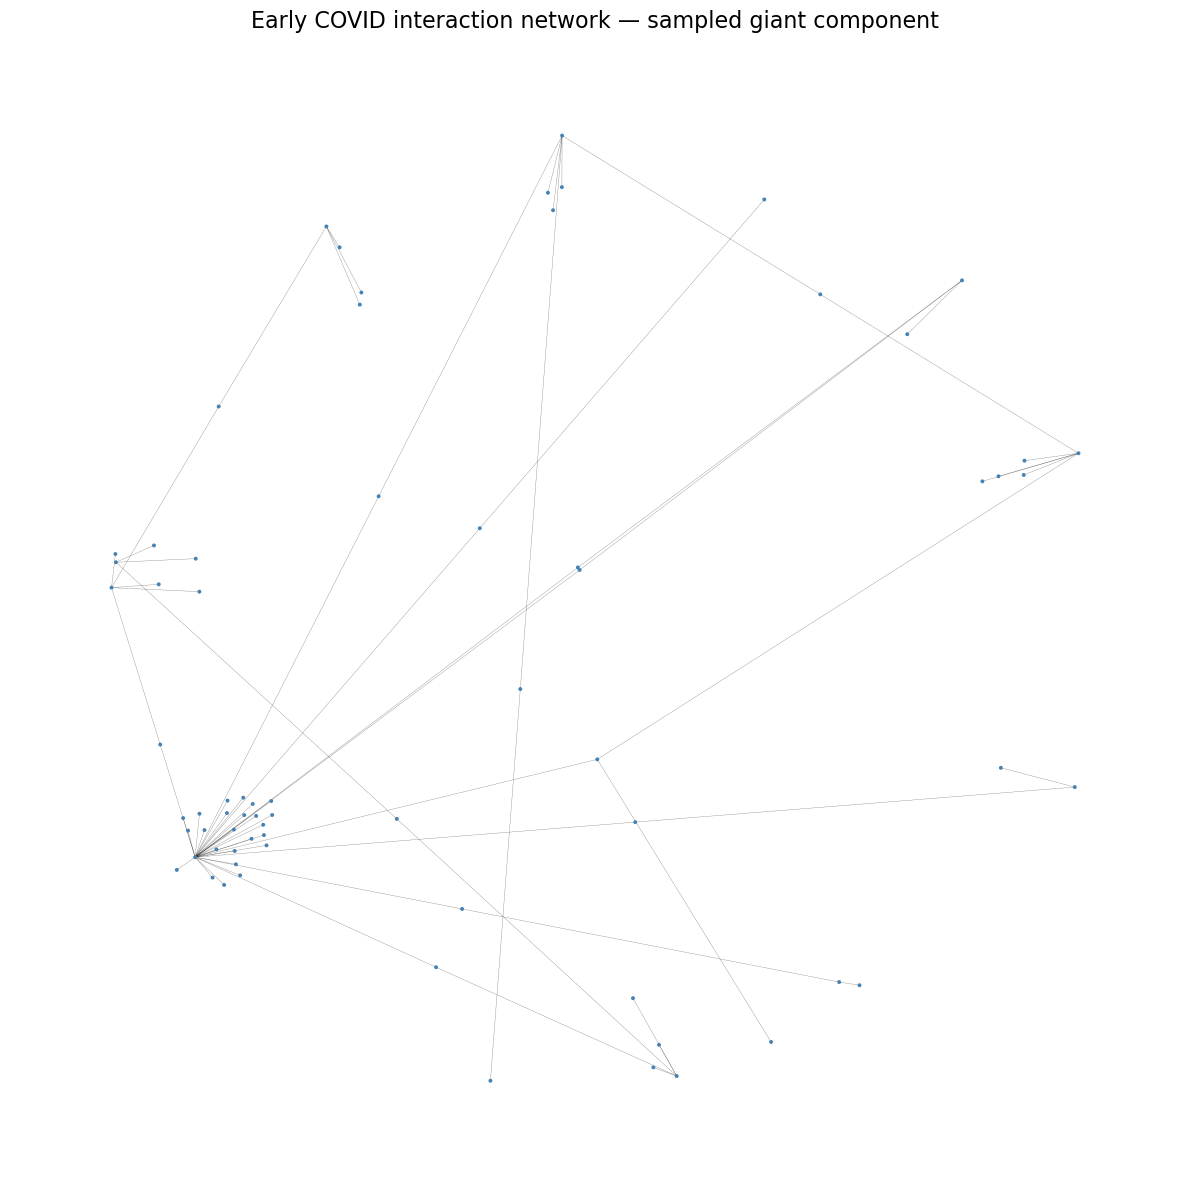

In [8]:
pos = nx.spring_layout(H, seed=seed, k=0.15, iterations=80)

fig, ax = plt.subplots(figsize=(12, 12), facecolor='white')

nx.draw_networkx_edges(
    H, pos,
    alpha=0.5,
    width=0.25,
    edge_color='black',
    arrows=False,
    ax=ax
)

nx.draw_networkx_nodes(
    H, pos,
    node_color='steelblue',
    node_size=8,
    edgecolors='none',
    ax=ax
)

ax.set_title('Early COVID interaction network — sampled giant component', fontsize=16)
ax.axis('off')

plt.tight_layout()
fig.savefig('early_covid_large_subgraph.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


## Variante più leggibile per slide

Se vuoi una rete meno densa e più facile da leggere in slide, prova un campione più piccolo e nodi più grandi.


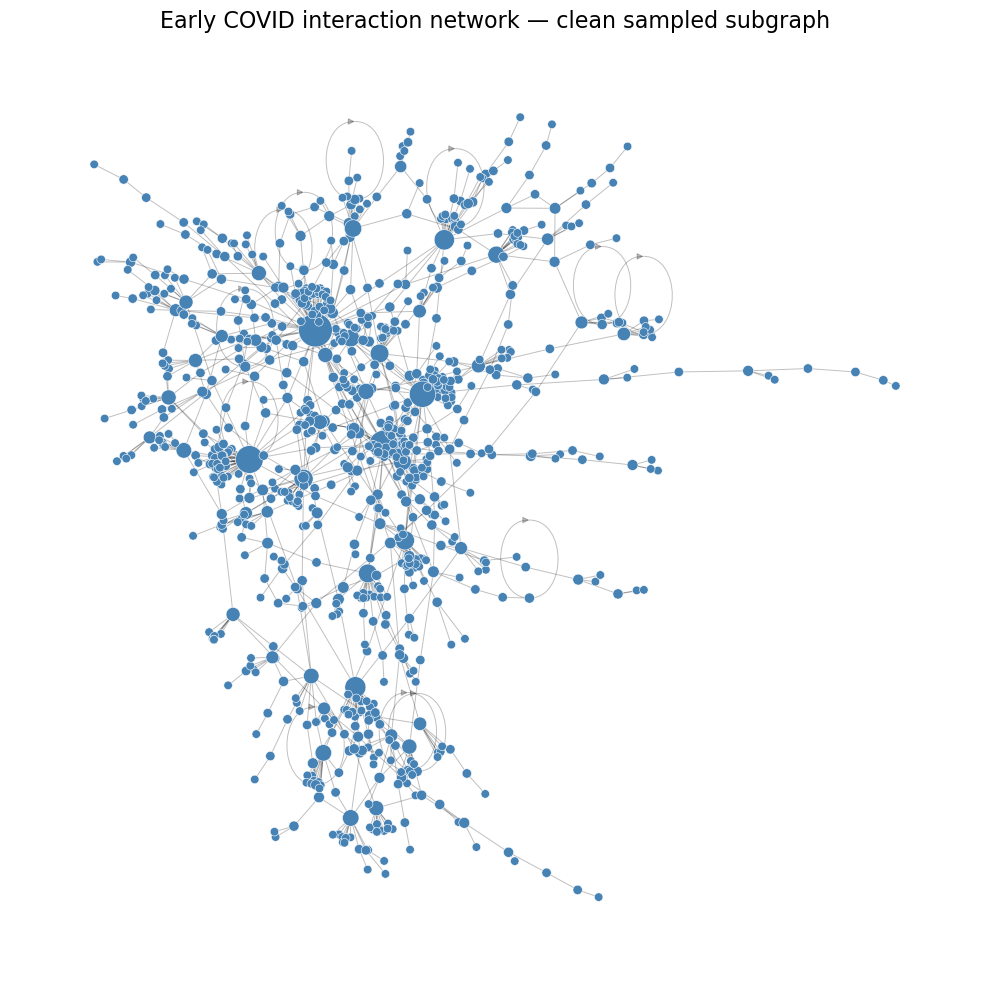

In [16]:
n_sample_small = 3250
random.seed(seed)

sampled_nodes_small = random.sample(list(Gcc.nodes()), min(n_sample_small, Gcc.number_of_nodes()))
Hs = Gcc.subgraph(sampled_nodes_small).copy()
Hs.remove_nodes_from(list(nx.isolates(Hs)))

if Hs.number_of_nodes() > 0:
    largest_sub_cc_small = max(nx.weakly_connected_components(Hs), key=len)
    Hs = Hs.subgraph(largest_sub_cc_small).copy()

pos_small = nx.spring_layout(Hs, seed=seed, k=0.7, iterations=100)

node_sizes = [30 + 8 * Hs.degree(n) for n in Hs.nodes()]

fig, ax = plt.subplots(figsize=(10, 10), facecolor='white')

nx.draw_networkx_edges(
    Hs, pos_small,
    alpha=0.25,
    width=0.7,
    edge_color='black',
    arrows=False,
    ax=ax
)

nx.draw_networkx_nodes(
    Hs, pos_small,
    node_color='steelblue',
    node_size=node_sizes,
    edgecolors='white',
    linewidths=0.4,
    ax=ax
)

ax.set_title('Early COVID interaction network — clean sampled subgraph', fontsize=16)
ax.axis('off')

plt.tight_layout()
fig.savefig('early_covid_clean_subgraph.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
